<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula05c%20-%20Multi%20Layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

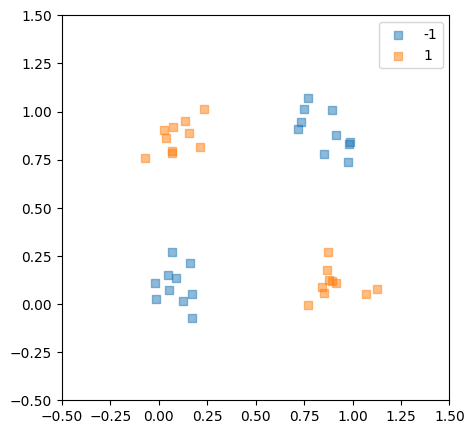

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

def createLogicalDataset(n=40, func= lambda a, b: bool(a) != bool(b)):
  X, y = make_blobs(n_samples=n,
                    centers=[[0.1,0.1], [0.9, 0.1], [0.1, 0.9], [0.9, 0.9]],
                    n_features=2,
                    cluster_std=0.1,
                    center_box=(0,1))
  y = np.array([func(a>0.5, b>0.5) for a, b in X], dtype=int)*2-1
  return X, y

def plotDataset(X, y, marker='s'):
  for i in sorted(list(set(y))):
    plt.scatter(X[y==i,0], X[y==i,1], label=f"{i}", alpha=0.5, marker=marker)
  plt.xlim(-0.5,1.5)
  plt.ylim(-0.5,1.5)
  plt.legend()

def plotHyperplan(vector, intercept, legend="hyperplan"):
    xs = np.array([0, 1])
    ys = -(vector[0] * xs + intercept) / vector[1]
    plt.plot(xs, ys, label=legend)
    plt.legend()

X, y = createLogicalDataset()
plt.figure(figsize=(5,5))
plotDataset(X, y)
plt.show()

In [ ]:
def defineAxes(X):
  offset = 2
  min1, max1 = X[:,0].min()-offset, X[:,0].max()+offset
  min2, max2 = X[:,1].min()-offset, X[:,1].max()+offset
  return [min1, max1, min2, max2]

def plotPredictions(model, X):
  axes = defineAxes(X)
  x0s = np.linspace(axes[0], axes[1], 100)
  x1s = np.linspace(axes[2], axes[3], 100)
  x0, x1 = np.meshgrid(x0s, x1s)
  X = np.c_[x0.ravel(), x1.ravel()]
  ypred = model.predict(X).reshape(x0.shape)
  plt.contourf(x0, x1, ypred, cmap=plt.cm.brg, alpha=0.2)


Accuracy: 1.0


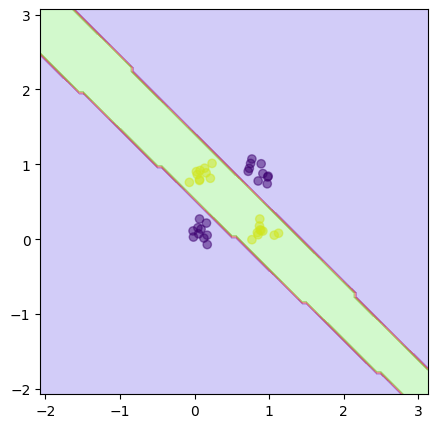

In [183]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.c_[np.ones(X.shape[0]), X]

class MultiLayer(BaseEstimator, ClassifierMixin):
  def __init__(self, n_hidden=[2], max_iter=20000, learning_rate=0.001):
    self.max_iter = max_iter
    self.learning_rate = learning_rate
    self.n_hidden = n_hidden
    self.activation = np.tanh

  def forward(self, X):
    self.A = []
    self.Z = []
    AUX = X.copy()
    for W in self.Ws:
      self.A.append(include_bias(AUX))
      self.Z.append(self.A[-1] @ W)
      AUX = self.activation(self.Z[-1])
    return AUX

  def backward(self, y, y_pred):
    grads = []
    output_delta = y_pred - y
    output_grad = self.A[-1].T @ output_delta
    grads.append(output_grad)
    for i in range(len(self.Ws)-1, 0, -1):
      tanh_grad = (1 - np.tanh(self.Z[i-1])**2)
      input_delta = output_delta @ self.Ws[i][1:].T * tanh_grad
      grad = self.A[i-1].T @ input_delta
      grads.insert(0, grad)
      output_delta = input_delta.copy()
    for i in range(len(self.Ws)):
      self.Ws[i] -= self.learning_rate * grads[i]
    return self

  def fit(self, X, y):
    self.Ws = []
    previous_output = X.shape[1]
    for n in self.n_hidden:
      self.Ws.append(np.random.randn(previous_output+1, n))
      previous_output = n
    if len(y.shape) == 1:
      y = y.reshape(-1,1)
    self.Ws.append(np.random.randn(previous_output+1, y.shape[1]))
    for _ in range(self.max_iter):
      logits = self.forward(X)
      self.backward(y, logits)
    return self

  def predict(self, X):
    logits = self.forward(X)
    y_pred = np.sign(logits)
    return y_pred.reshape(-1)

model = MultiLayer()
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, alpha=0.5)
plotPredictions(model, X)
plt.show()

Accuracy: 1.0


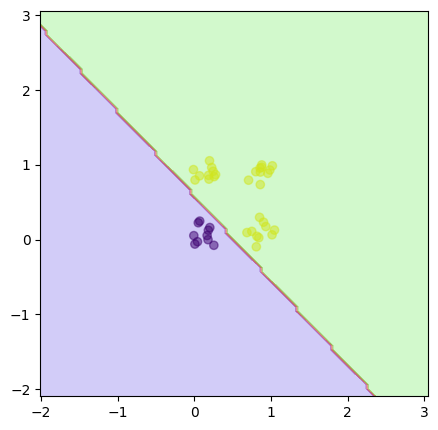

In [185]:
X, y = createLogicalDataset(func= lambda a, b: bool(a) or bool(b))
model = MultiLayer(n_hidden=[])
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, alpha=0.5)
plotPredictions(model, X)
plt.show()

Accuracy: 1.0


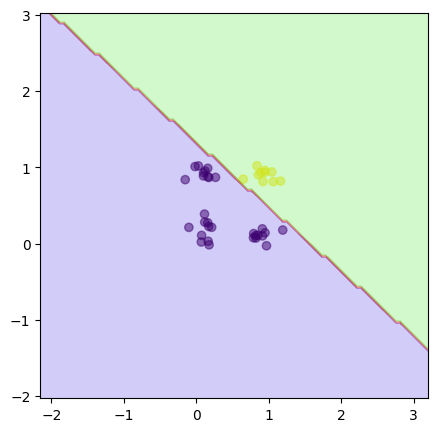

In [186]:
X, y = createLogicalDataset(func= lambda a, b: bool(a) and bool(b))
model = MultiLayer(n_hidden=[])
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, alpha=0.5)
plotPredictions(model, X)
plt.show()

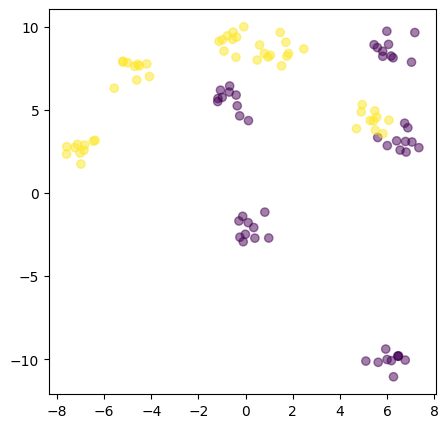

In [193]:
def make_hard_dataset(n=100, centers=10, cluster_std=0.5):
  X, y = make_blobs(n_samples=n, centers=centers, cluster_std=cluster_std)
  y = np.where(y%2 == 0, 1, -1)
  return X, y

X, y = make_hard_dataset()
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, alpha=0.5)
plt.show()

Accuracy: 1.0


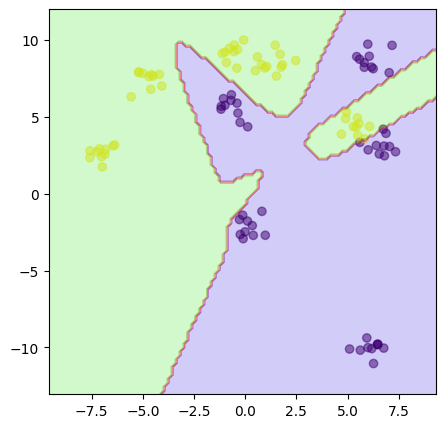

In [197]:
model = MultiLayer(n_hidden=[10])
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, alpha=0.5)
plotPredictions(model, X)
plt.show()

Accuracy: 1.0


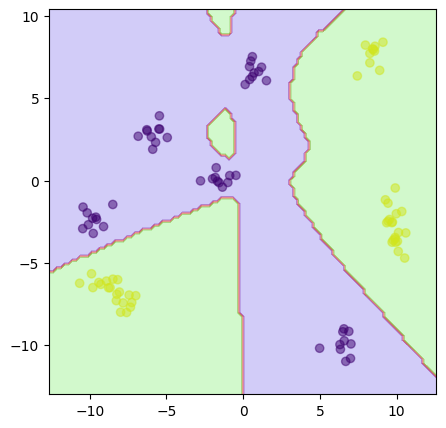

In [198]:
X, y = make_hard_dataset()
model = MultiLayer(n_hidden=[10])
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, alpha=0.5)
plotPredictions(model, X)
plt.show()

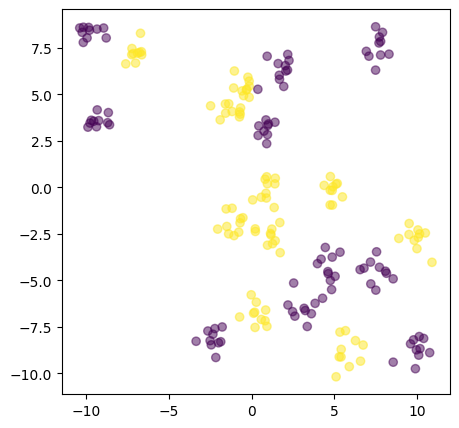

In [202]:
X, y = make_hard_dataset(200, 20)
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, alpha=0.5)
plt.show()

Accuracy: 1.0


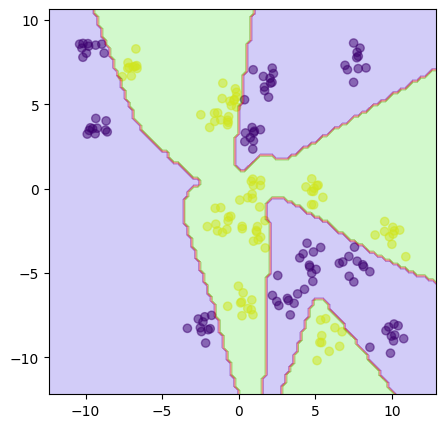

In [204]:
model = MultiLayer(n_hidden=[10, 10])
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, alpha=0.5)
plotPredictions(model, X)
plt.show()